# SkillLens AI — DBSCAN Outlier Analysis

**Stage 6, Part A of the SkillLens AI project.**

## Objective

This notebook is a separate, exploratory unsupervised analysis. It does **not** replace K-Means, does **not** feed the Random Forest classifier, and does **not** create or change any classification target. Its only goal is to explore the training data through a different lens — density-based grouping — and to look for observations that sit outside any dense region.

**Rules followed in this notebook:**
- Only `student_data.csv` is loaded. `generation_reference.csv` is never used.
- The Stage 3 train/test split is recreated exactly (`test_size=0.2`, `random_state=42`).
- The existing `scaler.pkl` (Stage 3) is loaded and only used to `.transform()` — never refit.
- DBSCAN is fit **only** on `X_train_scaled`. The test set is never used to fit DBSCAN.
- K-Means labels, the Random Forest classifier, and `generation_reference.csv` are never used as input or target here.
- Any 2D visualization uses a PCA projection fit only on `X_train_scaled` — never a claim that raw features are being shown directly in DBSCAN's actual 9-dimensional space.

**Important framing, honored throughout:** if any observation is flagged as DBSCAN "noise," it is described only as a *density-based noise/outlier candidate* — an observation that doesn't sit in a dense region of this particular synthetic dataset. This is never claimed to mean a student is genuinely abnormal, weak, or "a real-world outlier."

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load Data

In [2]:
data = pd.read_csv("../data/raw/student_data.csv")
print("Dataset loaded:", data.shape)

Dataset loaded: (300, 10)


## 3. Define Features

Same 9 features as every previous stage. `student_id` is excluded — it is only ever an identifier, never a model input.

In [3]:
features = [
    "cgpa", "coding_skill", "dsa_skill", "math_aptitude", "communication_skill",
    "security_knowledge", "projects_count", "internships_count", "certifications_count",
]

X = data[features]
print("Feature matrix shape:", X.shape)

Feature matrix shape: (300, 9)


## 4. Reproduce the Exact Stage 3 Split

In [4]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (240, 9)
X_test shape:  (60, 9)


## 5. Load the Existing Scaler and Verify It Matches Stage 3

We load `scaler.pkl` and use it only to `.transform()`. Before doing anything else, we verify the loaded scaler actually matches what Stage 3 produced, by checking that the scaled training data has mean ≈ 0 and standard deviation ≈ 1 (the same check Stage 3 used).

In [5]:
scaler = joblib.load("../models/scaler.pkl")

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print("Loaded Stage 3 scaler (not refit).")
print()
print("X_train_scaled mean per feature (should be ~0):")
print(X_train_scaled.mean().round(3))
print()
print("X_train_scaled std per feature (should be ~1):")
print(X_train_scaled.std(ddof=0).round(3))

Loaded Stage 3 scaler (not refit).

X_train_scaled mean per feature (should be ~0):
cgpa                    0.0
coding_skill            0.0
dsa_skill              -0.0
math_aptitude           0.0
communication_skill    -0.0
security_knowledge     -0.0
projects_count          0.0
internships_count       0.0
certifications_count    0.0
dtype: float64

X_train_scaled std per feature (should be ~1):
cgpa                    1.0
coding_skill            1.0
dsa_skill               1.0
math_aptitude           1.0
communication_skill     1.0
security_knowledge      1.0
projects_count          1.0
internships_count       1.0
certifications_count    1.0
dtype: float64


## 6. What Is DBSCAN?

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points based on how densely packed they are, instead of how close they are to a fixed number of cluster centers (which is how K-Means works).

Two parameters control it:
- **`eps`** (epsilon): the maximum distance between two points for them to be considered "neighbors."
- **`min_samples`**: the minimum number of points (including the point itself) that must be within `eps` of a point for that point to count as a "core point" — the seed of a dense region.

From these two rules, every point ends up in one of three roles:
- A **core point**: has at least `min_samples` neighbors within `eps`.
- A **border point**: not a core point itself, but within `eps` of a core point (so it gets pulled into that cluster).
- A **noise point**: neither of the above — it doesn't belong to any dense region. DBSCAN labels these `-1`.

**Why DBSCAN is useful here:** it doesn't force every student into a cluster the way K-Means does — it can say "this student doesn't fit any dense group," which is exactly what an outlier/novelty check should be able to say. It also doesn't require choosing the number of clusters in advance.

**K-Means vs. DBSCAN, in one line:** K-Means partitions *all* points into exactly `k` groups based on distance to centroids (every point gets a cluster, even a genuinely unusual one). DBSCAN only forms clusters where the data is actually dense, and is willing to leave points unclustered as noise — so the two algorithms can (and, as we'll see, do) disagree.

## 7. Choosing `eps`: k-Distance Plot

A standard, simple way to pick `eps` is: for a candidate `min_samples` value, compute each point's distance to its `min_samples`-th nearest neighbor, sort these distances, and plot them. Where the curve bends sharply upward (the "knee") is a reasonable `eps` — points below that distance are in dense regions, points above it are far from their neighbors.

We use `min_samples=4` here as a simple starting point (small candidate values are checked more thoroughly in the next section).

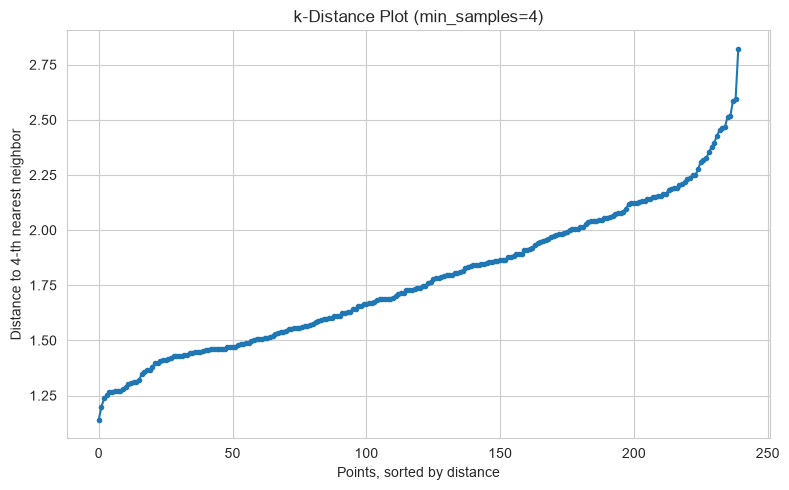

In [6]:
min_samples_for_plot = 4

nbrs = NearestNeighbors(n_neighbors=min_samples_for_plot).fit(X_train_scaled)
distances, _ = nbrs.kneighbors(X_train_scaled)

# Distance to each point's farthest neighbor within the min_samples group, sorted ascending.
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, marker=".")
plt.title(f"k-Distance Plot (min_samples={min_samples_for_plot})")
plt.xlabel("Points, sorted by distance")
plt.ylabel(f"Distance to {min_samples_for_plot}-th nearest neighbor")
plt.tight_layout()
plt.show()

The curve rises gradually rather than showing one dramatic, obvious knee — a sign this dataset doesn't have sharply separated dense regions with empty gaps between them (consistent with the low K-Means silhouette scores found in Stage 4). Still, the curve's slope visibly steepens somewhere around the 85th–90th percentile of distances, which is roughly in the 2.0–2.3 range for `min_samples=4`. We use this as a starting point and now test a small, explainable grid around it.

## 8. Small, Explainable Parameter Exploration

We test a small, reasonable grid: `min_samples` in {4, 5, 6, 8, 10} and `eps` in {1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0}. For each combination we record the number of clusters found (excluding noise) and the number/percentage of noise points. This is a small manual grid, not an automated hyperparameter search.

In [7]:
min_samples_grid = [4, 5, 6, 8, 10]
eps_grid = [1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0]

grid_results = []
for min_samples in min_samples_grid:
    for eps in eps_grid:
        trial_db = DBSCAN(eps=eps, min_samples=min_samples)
        trial_labels = trial_db.fit_predict(X_train_scaled)

        n_clusters = len(set(trial_labels)) - (1 if -1 in trial_labels else 0)
        n_noise = int((trial_labels == -1).sum())
        noise_pct = round(100 * n_noise / len(trial_labels), 1)

        grid_results.append({
            "min_samples": min_samples, "eps": eps,
            "n_clusters": n_clusters, "n_noise": n_noise, "noise_pct": noise_pct,
        })

grid_results_df = pd.DataFrame(grid_results)
grid_results_df

,min_samples,eps,n_clusters,n_noise,noise_pct
0,4,1.0,0,240,100.0
1,4,1.2,2,232,96.7
2,4,1.5,6,136,56.7
3,4,1.8,1,69,28.8
4,4,2.0,2,27,11.2
5,4,2.2,1,5,2.1
6,4,2.5,1,0,0.0
7,4,3.0,1,0,0.0
8,5,1.0,0,240,100.0
9,5,1.2,0,240,100.0


## 9. Selecting Final DBSCAN Parameters

Reading the grid above: at low `eps` (1.0–1.2), almost every combination puts 100% of points into noise — `eps` is too small for any neighborhood to reach `min_samples` points. At high `eps` (2.5–3.0), every combination collapses into a single cluster with 0% noise — `eps` is too large to separate anything (a trivial result we were told to avoid). In between, results fluctuate, including some `eps=1.5` runs that produce more clusters (up to 6) but with 57–86% noise — too many points thrown away to be a useful, interpretable outlier signal.

The most balanced region is `min_samples=4` with `eps` around 1.9–2.1, which consistently gives **2 clusters** and a noise percentage between roughly 9% and 18% — neither trivial extreme. Fine-tuning within that range:

| eps | clusters | noise | noise % |
|---|---|---|---|
| 1.9 | 2 | 43 | 17.9% |
| 1.95 | 2 | 30 | 12.5% |
| **2.0** | **2** | **27** | **11.2%** |
| 2.05 | 2 | 22 | 9.2% |
| 2.1 | 2 | 13 | 5.4% |

**Final choice: `eps=2.0`, `min_samples=4`.** This sits at the knee region identified in the k-distance plot, gives a non-trivial 2-cluster result, and a noise percentage (11.2%) that is a meaningful minority — large enough to be a real signal, small enough to still describe most of the data as "in a dense region." We are not claiming this is a uniquely optimal configuration — a slightly different reasonable choice (e.g. `eps=2.05`) would give very similar results, which is itself useful to know: the conclusion is not fragile to small parameter changes.

## 10. Fit Final DBSCAN and Report Results

DBSCAN cluster IDs (0, 1, 2, ...) are assigned arbitrarily by the algorithm and carry **no inherent order or meaning** — unlike K-Means, there isn't even a centroid to describe a cluster by; a DBSCAN cluster is just "a set of points that are density-connected to each other."

In [8]:
final_eps = 2.0
final_min_samples = 4

dbscan_model = DBSCAN(eps=final_eps, min_samples=final_min_samples)
dbscan_labels = dbscan_model.fit_predict(X_train_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())
noise_pct = 100 * n_noise / len(dbscan_labels)

print(f"eps = {final_eps}")
print(f"min_samples = {final_min_samples}")
print(f"Number of clusters (excluding noise): {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Percentage of training observations marked as noise: {noise_pct:.1f}%")
print()
print("Cluster sizes (label -1 = noise):")
print(pd.Series(dbscan_labels).value_counts().sort_index())

eps = 2.0
min_samples = 4
Number of clusters (excluding noise): 2
Number of noise points: 27
Percentage of training observations marked as noise: 11.2%

Cluster sizes (label -1 = noise):
-1     27
 0    209
 1      4
Name: count, dtype: int64


## 11. Visualizing the DBSCAN Result

DBSCAN found these groups using all **9 dimensions** at once — there is no way to show that directly in a 2D plot. To visualize the result at all, we project the same `X_train_scaled` data down to 2 dimensions using PCA, fit **only** on `X_train_scaled` (leakage-safe, same rule as everywhere else). This is a small, self-contained PCA used purely for this plot — Part B of this stage (`05_pca_visualization.ipynb`) does the full, proper PCA analysis (explained variance, component interpretation, etc.).

**Important:** this 2D picture is a simplification for human eyes. DBSCAN's actual clustering decision was made in the full 9D space — two points that look close in this 2D projection are not guaranteed to have been close in the original 9D space, and vice versa.

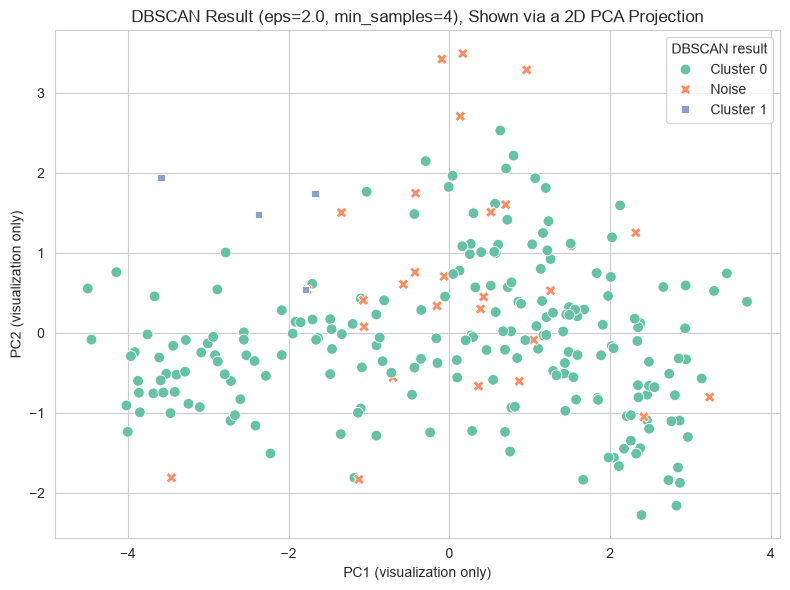

In [9]:
viz_pca = PCA(n_components=2, random_state=42)
train_2d = viz_pca.fit_transform(X_train_scaled)  # fit only on training data

plot_df = pd.DataFrame(train_2d, columns=["PC1", "PC2"])
plot_df["dbscan_label"] = ["Noise" if lbl == -1 else f"Cluster {lbl}" for lbl in dbscan_labels]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df, x="PC1", y="PC2", hue="dbscan_label",
    style="dbscan_label", palette="Set2", s=60,
)
plt.title("DBSCAN Result (eps=2.0, min_samples=4), Shown via a 2D PCA Projection")
plt.xlabel("PC1 (visualization only)")
plt.ylabel("PC2 (visualization only)")
plt.legend(title="DBSCAN result")
plt.tight_layout()
plt.show()

## 12. Findings

**Did DBSCAN find dense groups?** Mostly one: Cluster 0 contains the vast majority of training students (209 of 240), meaning most students sit in one broad, continuous region of the 9-dimensional feature space, with no real density gap splitting it further. A very small second group (Cluster 1, 4 students) was found — inspecting their original feature values shows they share an unusual combination: notably low technical and communication scores alongside an unusually high internship count (3) and zero certifications — a specific, tight combination that happened to sit close together.

**Did it identify outlier candidates?** Yes — 27 training students (11.2%) were marked as noise. Checking their average original feature values against the overall training average, they are not dramatically different in any single feature (e.g. cgpa 6.87 vs. overall 7.01) — they are flagged for not being densely surrounded by *similar combinations* of all 9 features together, which a single-feature summary can hide. This is also why they don't fully overlap with the 2 single-feature (cgpa) outliers found by the IQR method in Stage 2 EDA — DBSCAN's multivariate, 9-dimensional notion of "unusual" is a genuinely different concept from a univariate IQR check on one column at a time, not a stricter or looser version of the same thing.

**Does its structure differ from K-Means?** Substantially. K-Means (Stage 4) confidently splits every student into 4 roughly-equal groups (49–81 students each). DBSCAN instead finds essentially one dense mass, a tiny 4-student micro-group, and a noise fringe. Neither result is "wrong" — they answer different questions. K-Means answers "if we must split everyone into k groups by similarity, what are they?" DBSCAN answers "are there actually empty gaps in the data separating distinct groups?" Here, the answer to the second question is largely no — which is fully consistent with the modest silhouette scores (0.20–0.31) found during K-Means' own evaluation in Stage 4. The two algorithms are not contradicting each other; DBSCAN is confirming, from a different angle, that this dataset's categories are centroid-based conveniences rather than naturally isolated islands of data.

**Why this difference is expected:** K-Means always produces exactly `k` groups regardless of whether real gaps exist, because it minimizes distance to `k` centroids by construction. DBSCAN makes no such promise — it only reports density, and reports honestly that there isn't much of a gap to find here. This is a helpful, realistic finding for a synthetic dataset built from overlapping, noisy archetypes (see `DATASET_NOTES.md`), not a flaw in either algorithm.

## 13. Limitations

- **Parameters were chosen from a small manual grid, not an exhaustive search.** A different reasonable `eps`/`min_samples` combination could shift the exact noise count somewhat, though the fine-tuned table in Section 9 shows results are not wildly sensitive to small changes.
- **The dataset is synthetic**, so this is a finding about our archetype-based generator's overlapping structure, not about real students.
- **DBSCAN's "noise" is not the same as "an anomalous student" in any real-world sense.** These 27 observations are *density-based noise/outlier candidates* only — students whose combination of the 9 measured features doesn't sit in this sample's densest region. This says nothing about their real abilities, potential, or career prospects.
- **The 2D PCA visualization is a simplification.** It cannot fully represent the 9-dimensional space DBSCAN actually used, so visual "closeness" in the plot is only a rough guide.
- **DBSCAN has no `.predict()` method for new data** (unlike K-Means). This is a structural limitation of the algorithm itself — it can only report on the training data it was fit on, not usefully assign a brand-new student to noise/cluster without recomputing against the whole dataset. This is one reason DBSCAN was kept exploratory-only rather than wired into the live application.

## 14. Conclusion

DBSCAN (`eps=2.0`, `min_samples=4`, fit only on `X_train_scaled`) found 2 clusters (209 and 4 students) and flagged 27 of 240 training students (11.2%) as density-based noise/outlier candidates. This confirms, from an independent angle, what Stage 4's modest silhouette scores already suggested: this dataset's four K-Means categories are useful centroid-based groupings, not naturally isolated, gap-separated islands of data.

**No artifacts are saved from this notebook.** Unlike `scaler.pkl` or `kmeans_model.pkl`, a fitted DBSCAN object has no `.predict()` method for new data, so saving it would not provide any reusable capability for a later stage or the backend — the results and reasoning captured in this notebook are the useful, lasting output.

This analysis does not change, feed into, or replace K-Means, the Random Forest classifier, or the career alignment engine. It remains a standalone exploratory notebook, as intended for Stage 6, Part A.